# Evolution of Copper Production in Chile

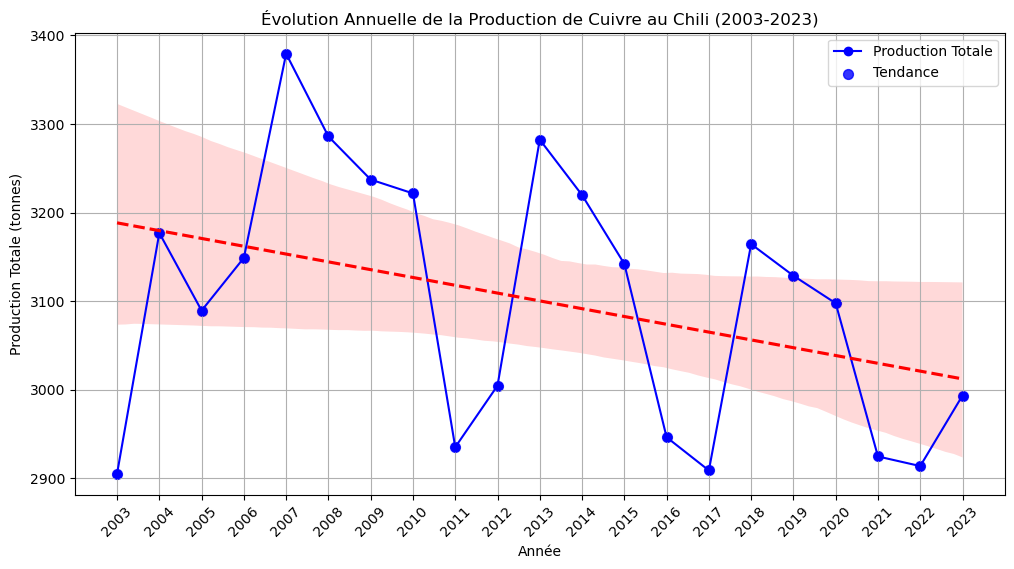

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Charger les données
file_path = "final_merged_data.csv"
df = pd.read_csv(file_path, parse_dates=["Date"])

# Extraire uniquement l'année et agréger la production annuellement
df["Year"] = df["Date"].dt.year
df_yearly = df.groupby("Year")["Production"].sum().reset_index()

# Définir l'intervalle des années (2003-2023)
years_range = np.arange(2003, 2024, 1)  # Assure qu'on affiche toutes les années entières

# Créer le graphique
plt.figure(figsize=(12, 6))

# Relier tous les points avec une ligne bleue
plt.plot(df_yearly["Year"], df_yearly["Production"], color="blue", marker="o", linestyle="-", label="Production Totale")

# Ajouter une courbe de tendance en pointillés rouges
sns.regplot(x=df_yearly["Year"], y=df_yearly["Production"], scatter=True, color="blue",
            line_kws={"color": "red", "linestyle": "--"}, scatter_kws={"s": 50})

# Ajuster les ticks de l'axe des X
plt.xticks(years_range, rotation=45)  # Affiche toutes les années entre 2003 et 2023

# Ajouter les labels et titre
plt.xlabel("Année")
plt.ylabel("Production Totale (tonnes)")
plt.title("Évolution Annuelle de la Production de Cuivre au Chili (2003-2023)")
plt.legend(["Production Totale", "Tendance"])
plt.grid(True)

# ✅ Sauvegarder l’image en format PDF (compatibilité LaTeX)
plt.savefig("production_cuivre.pdf", format="pdf", bbox_inches="tight")

# Afficher le graphique
plt.show()


# Regression plots: Production vs. Key  Variables

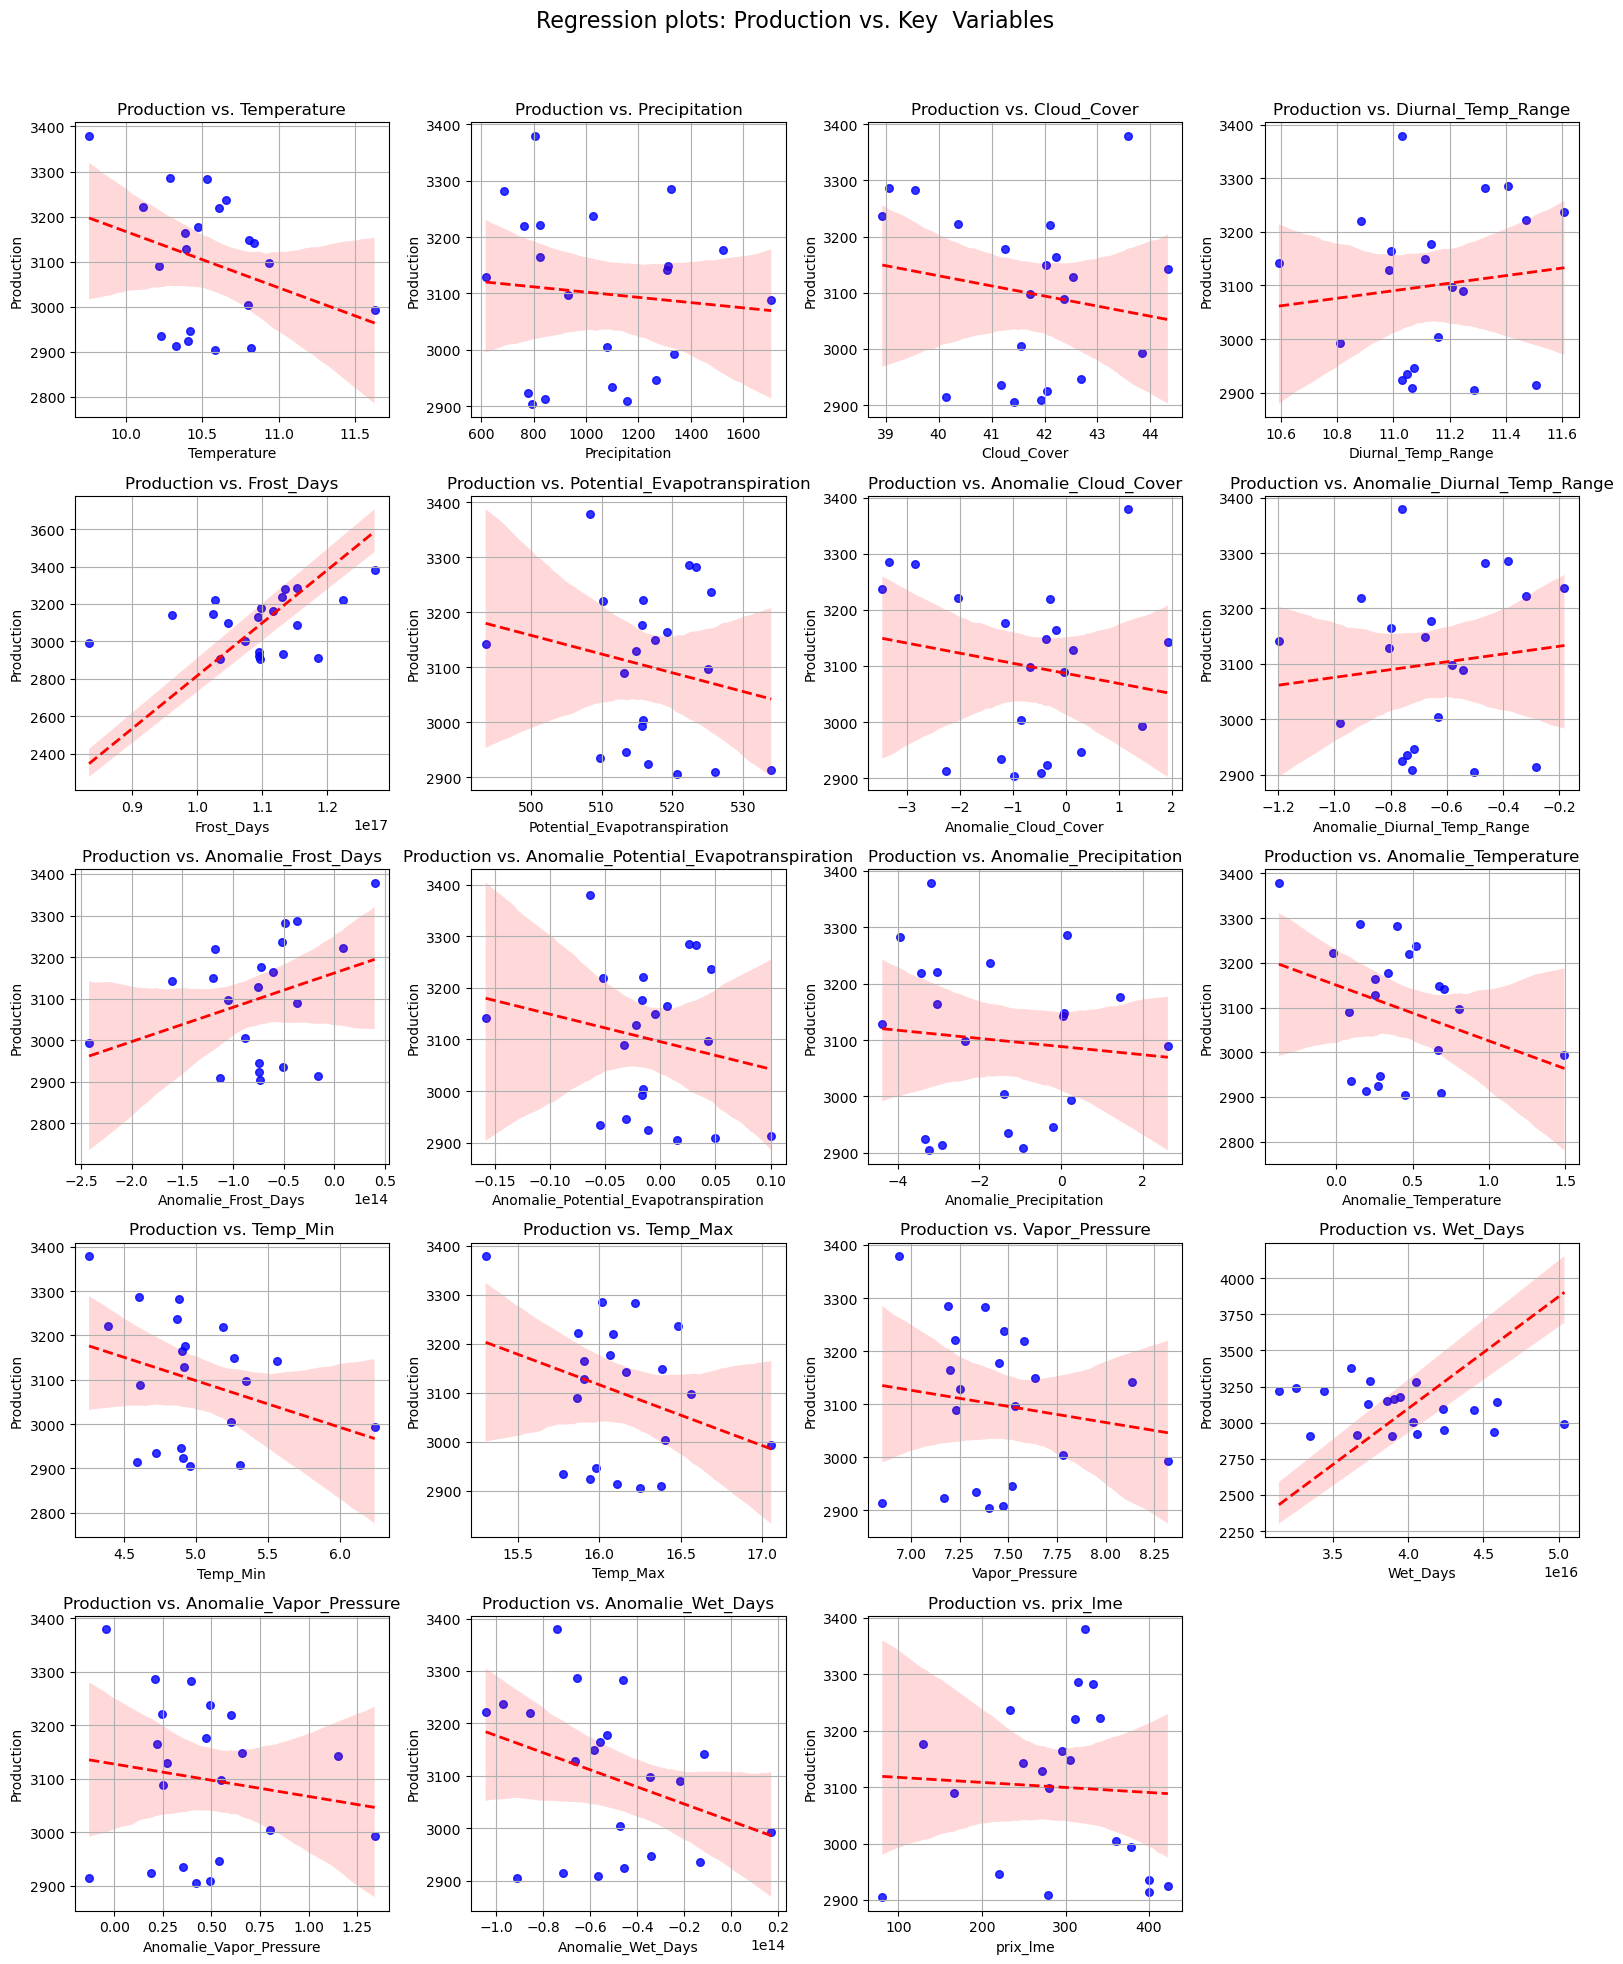

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------------
# 1. Préparation du DataFrame
# ----------------------------------------------------------------------------
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

# Agrégation par année (exemple : somme pour Production, moyenne pour d’autres variables)
df_annual = df.groupby("Year", as_index=False).agg({
    # Ajustez selon votre logique
    "Production": "sum",
    "Temperature": "mean",
    "Precipitation": "sum",
    "Cloud_Cover": "mean",
    "Diurnal_Temp_Range": "mean",
    "Frost_Days": "sum",
    "Potential_Evapotranspiration": "sum",
    "Anomalie_Cloud_Cover": "mean",
    "Anomalie_Diurnal_Temp_Range": "mean",
    "Anomalie_Frost_Days": "mean",
    "Anomalie_Potential_Evapotranspiration": "mean",
    "Anomalie_Precipitation": "mean",
    "Anomalie_Temperature": "mean",
    "Temp_Min": "mean",
    "Temp_Max": "mean",
    "Vapor_Pressure": "mean",
    "Wet_Days": "sum",
    "Anomalie_Vapor_Pressure": "mean",
    "Anomalie_Wet_Days": "mean",
    "prix_lme": "mean"
    
})

# Assurer l'affichage de toutes les années de 2003 à 2023
all_years = list(range(2003, 2024))
all_years_df = pd.DataFrame({"Year": all_years})
df_annual_complete = pd.merge(all_years_df, df_annual, on="Year", how="left")

# (Optionnel) Remplacer les valeurs manquantes
# df_annual_complete.fillna(0, inplace=True)

# ----------------------------------------------------------------------------
# 2. Sélection des variables à tracer
# ----------------------------------------------------------------------------
key_vars = [
    "Production", "Temperature", "Precipitation", "Cloud_Cover", "Diurnal_Temp_Range",
    "Frost_Days", "Potential_Evapotranspiration", "Anomalie_Cloud_Cover",
    "Anomalie_Diurnal_Temp_Range", "Anomalie_Frost_Days",
    "Anomalie_Potential_Evapotranspiration", "Anomalie_Precipitation", "Anomalie_Temperature",
    "Temp_Min", "Temp_Max", "Vapor_Pressure", "Wet_Days", "Anomalie_Vapor_Pressure",
    "Anomalie_Wet_Days", "prix_lme"
]

# On ne veut tracer que la relation "Production" vs chaque variable différente de "Production"
climate_vars = [v for v in key_vars if v != "Production"]

# ----------------------------------------------------------------------------
# 3. Création des subplots
# ----------------------------------------------------------------------------
n = len(climate_vars)
ncols = 4  # nombre de colonnes (à ajuster)
nrows = (n + ncols - 1) // ncols  # calcule le nombre de lignes nécessaire

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten()  # pour itérer facilement sur les axes

for i, var in enumerate(climate_vars):
    ax = axes[i]
    sns.regplot(
        x=var,
        y="Production",
        data=df_annual_complete,
        ci=95,  # Intervalle de confiance
        scatter_kws={"color": "blue", "s": 30},  # s=taille des points
        line_kws={"color": "red", "linestyle": "--", "linewidth": 2},
        ax=ax
    )
    ax.set_title(f"Production vs. {var}")
    ax.grid(True)

# Si le nombre total de subplots est supérieur au nombre de variables,
# on masque les axes inutilisés
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Regression plots: Production vs. Key  Variables", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])  # Laisser de la place au titre
plt.savefig("production_vs_climate_regressions.pdf", format="pdf")
plt.show()
